In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
path = "Student Depression Dataset.csv"
df = pd.read_csv('/home/shrihari_006/programming/Student_Depression/Model Training/Student_Depression_Dataset.csv')
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [10]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [12]:
df.isnull().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [13]:
x = df['Financial Stress'].median()
print(x)
df['Financial Stress'].fillna(x, inplace=True)

3.0


/tmp/ipykernel_12701/2513825591.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Financial Stress'].fillna(x, inplace=True)


In [14]:
df = df.drop(['id'],inplace = False,axis = 1)


In [15]:
print(df.groupby('Depression')['Financial Stress'].mean())
print(df.groupby('Depression')['Age'].mean())
print(df.groupby('Gender')['Depression'].count())
print(df.groupby('Depression')['Academic Pressure'].mean())
print(df.groupby('Depression')['CGPA'].mean())
print(df.groupby('Depression')['Study Satisfaction'].mean())



Depression
0    2.518807
1    3.579518
Name: Financial Stress, dtype: float64
Depression
0    27.142412
1    24.887733
Name: Age, dtype: float64
Gender
Female    12354
Male      15547
Name: Depression, dtype: int64
Depression
0    2.361608
1    3.693132
Name: Academic Pressure, dtype: float64
Depression
0    7.617282
1    7.683588
Name: CGPA, dtype: float64
Depression
0    3.215564
1    2.751469
Name: Study Satisfaction, dtype: float64


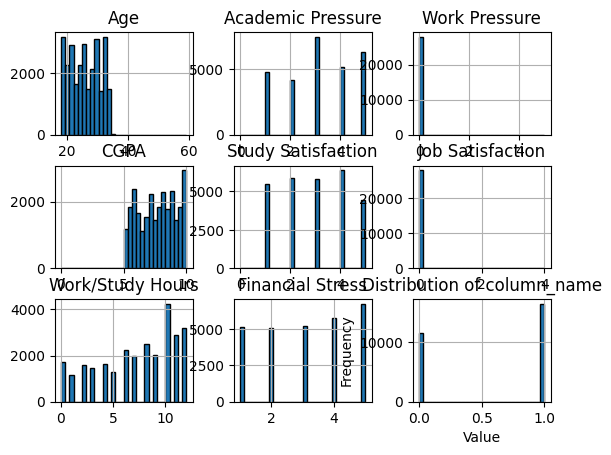

In [16]:
df.hist(bins=30, edgecolor='black')
plt.title('Distribution of column_name')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

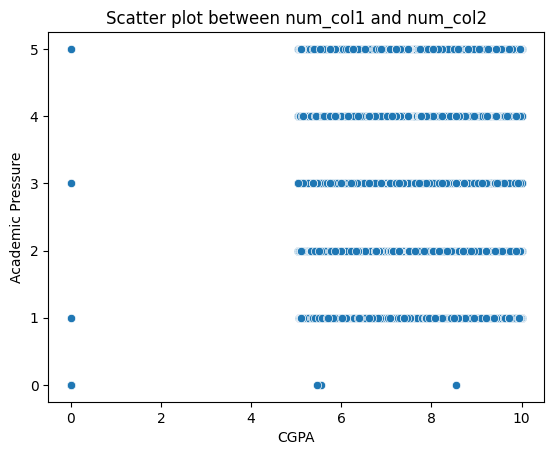

In [17]:
sns.scatterplot(x=df['CGPA'], y=df['Academic Pressure'])
plt.title('Scatter plot between num_col1 and num_col2')
plt.show()


In [18]:
df['Profession'].value_counts()

Profession
Student                   27870
Architect                     8
Teacher                       6
Digital Marketer              3
Chef                          2
Content Writer                2
Pharmacist                    2
Doctor                        2
UX/UI Designer                1
Civil Engineer                1
Manager                       1
Educational Consultant        1
Lawyer                        1
Entrepreneur                  1
Name: count, dtype: int64

In [19]:
df = df[df['Profession'] == 'Student']
df.count()

Gender                                   27870
Age                                      27870
City                                     27870
Profession                               27870
Academic Pressure                        27870
Work Pressure                            27870
CGPA                                     27870
Study Satisfaction                       27870
Job Satisfaction                         27870
Sleep Duration                           27870
Dietary Habits                           27870
Degree                                   27870
Have you ever had suicidal thoughts ?    27870
Work/Study Hours                         27870
Financial Stress                         27870
Family History of Mental Illness         27870
Depression                               27870
dtype: int64

In [20]:
df.drop(['Profession', 'Work Pressure', 'Job Satisfaction'], axis=1, inplace=True)


In [21]:
df

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,Female,27.0,Surat,5.0,5.75,5.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,Male,27.0,Ludhiana,2.0,9.40,3.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,Male,31.0,Faridabad,3.0,6.61,4.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,Female,18.0,Ludhiana,5.0,6.88,2.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


In [37]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Encode categorical columns
label_encoder = LabelEncoder()
for column in ['Gender', 'Degree', 'City', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Sleep Duration', 'Family History of Mental Illness']:
    if column in df.columns:
        df[column] = label_encoder.fit_transform(df[column])
    else:
        print(f"Column '{column}' not found in the DataFrame.")

# Separate features and target
X = df.drop('Depression', axis=1)
y = df['Depression']

# Apply SMOTE to balance the 'Depression' column
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Combine resampled data into a new DataFrame
df_resampled = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.DataFrame(y_resampled, columns=['Depression'])], axis=1)

df_resampled

Column 'Gender' not found in the DataFrame.
Column 'Degree' not found in the DataFrame.
Column 'City' not found in the DataFrame.
Column 'Family History of Mental Illness' not found in the DataFrame.


/tmp/ipykernel_12701/1926947742.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = label_encoder.fit_transform(df[column])
/tmp/ipykernel_12701/1926947742.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = label_encoder.fit_transform(df[column])
/tmp/ipykernel_12701/1926947742.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

,Sleep Duration,Academic Pressure,Dietary Habits,Work/Study Hours,Financial Stress,Have you ever had suicidal thoughts ?,Depression
0,0,1.0,0,0.250000,0.00,1,1
1,0,0.4,1,0.250000,0.25,0,0
2,2,0.6,0,0.750000,0.00,0,0
3,1,0.6,1,0.333333,1.00,1,1
4,0,0.8,1,0.083333,0.00,1,0
...,...,...,...,...,...,...,...
32611,1,0.2,3,0.500000,0.25,1,0
32612,2,0.8,0,0.879934,1.00,0,0
32613,2,0.4,1,0.416667,0.50,0,0
32614,3,0.4,0,0.803272,0.25,0,0


In [39]:
df = df_resampled
df['Depression'].value_counts()

Depression
1    16308
0    16308
Name: count, dtype: int64

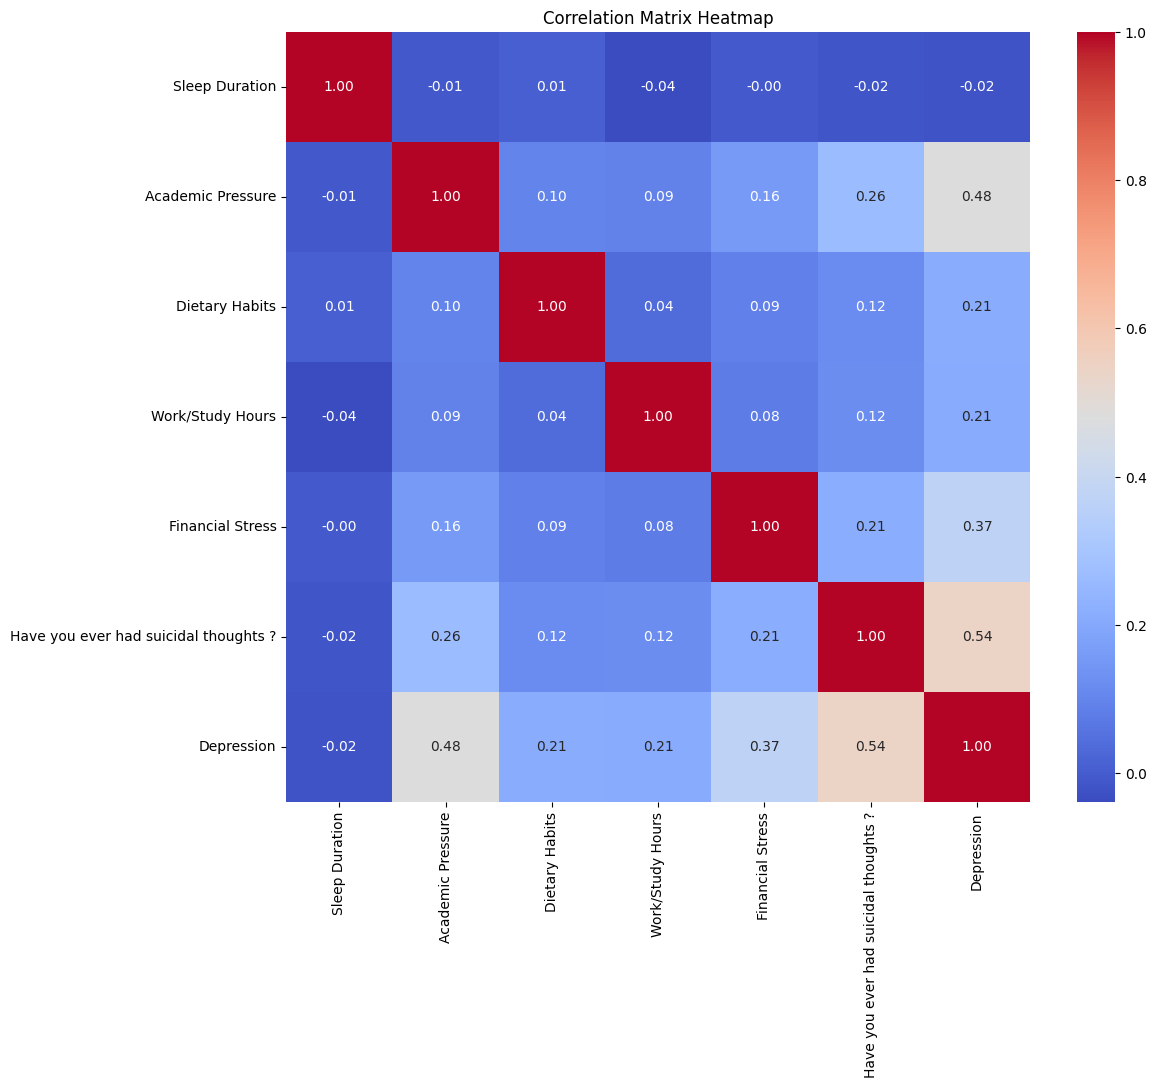

In [40]:
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [44]:
from sklearn.feature_selection import f_classif
import pandas as pd

# Select numerical features
numerical_features = ['Sleep Duration','Academic Pressure','Work/Study Hours','Financial Stress']  # Add other numerical columns if present

# Perform ANOVA F-test
f_scores, p_values = f_classif(df[numerical_features], df['Depression'])

# Store results in a DataFrame
anova_results = pd.DataFrame({'Feature': numerical_features, 'F-Score': f_scores, 'p-value': p_values})

# Print results
print(anova_results)


             Feature      F-Score        p-value
0     Sleep Duration    14.747054   1.231718e-04
1  Academic Pressure  9828.251803   0.000000e+00
2   Work/Study Hours  1482.272890  3.584237e-317
3   Financial Stress  5189.085377   0.000000e+00


In [45]:
from sklearn.preprocessing import StandardScaler

# Select the numerical features you want to standardize
numerical_features = ['Sleep Duration',  'Academic Pressure', 'Work/Study Hours', 'Financial Stress','Dietary Habits']

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to your data and transform it
df[numerical_features] = scaler.fit_transform(df[numerical_features])

In [47]:
from sklearn.preprocessing import MinMaxScaler

# Select the numerical features you want to normalize
numerical_features = ['Sleep Duration', 'Academic Pressure', 'Dietary Habits','Work/Study Hours', 'Financial Stress']

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Fit the scaler to your data and transform it
df[numerical_features] = scaler.fit_transform(df[numerical_features])

In [48]:
df_final = df[['Sleep Duration', 'Academic Pressure', 'Dietary Habits', 'Work/Study Hours', 'Financial Stress', 'Have you ever had suicidal thoughts ?','Depression']]
df = df_final

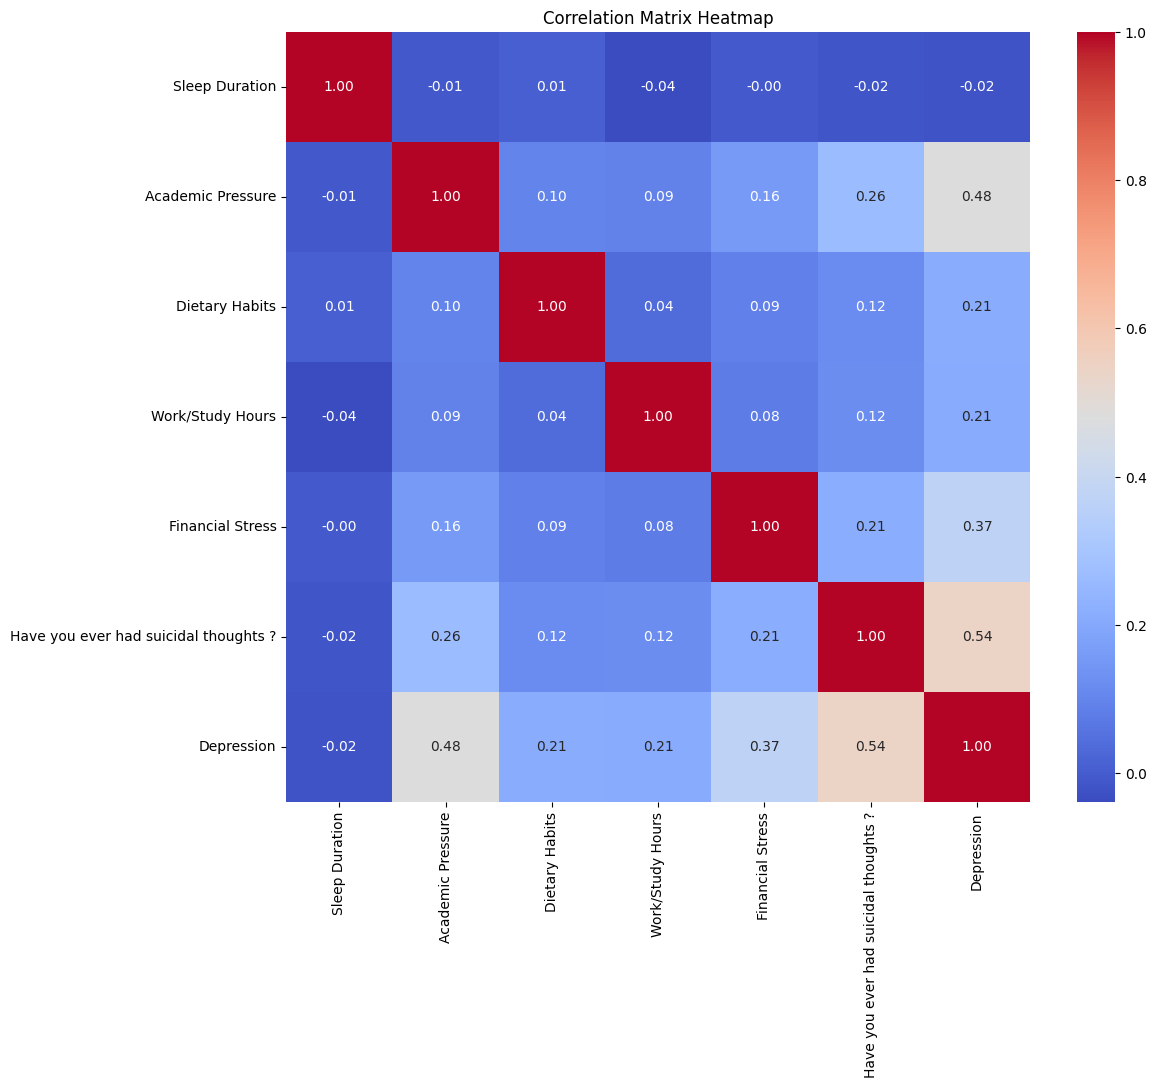

In [49]:
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [50]:
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from sklearn.model_selection import train_test_split

X = df.drop('Depression', axis=1)  # Features
y = df['Depression']  # Target variable

smote = SMOTE(random_state=42)  # Initialize SMOTE
X_resampled, y_resampled = smote.fit_resample(X, y)  # Resample the data

smote_enn = SMOTEENN(random_state=42)  # Initialize SMOTEENN
X_resampled_enn, y_resampled_enn = smote_enn.fit_resample(X, y)  # Resample the data

In [51]:
df

,Sleep Duration,Academic Pressure,Dietary Habits,Work/Study Hours,Financial Stress,Have you ever had suicidal thoughts ?,Depression
0,0.00,1.0,0.000000,0.250000,0.00,1,1
1,0.00,0.4,0.333333,0.250000,0.25,0,0
2,0.50,0.6,0.000000,0.750000,0.00,0,0
3,0.25,0.6,0.333333,0.333333,1.00,1,1
4,0.00,0.8,0.333333,0.083333,0.00,1,0
...,...,...,...,...,...,...,...
32611,0.25,0.2,1.000000,0.500000,0.25,1,0
32612,0.50,0.8,0.000000,0.879934,1.00,0,0
32613,0.50,0.4,0.333333,0.416667,0.50,0,0
32614,0.75,0.4,0.000000,0.803272,0.25,0,0


In [56]:
df.to_csv("Processed_data.csv", index=False)